# Python Setup and Imports



In [1]:
# --- Upgrade required packages ---
!pip install --upgrade statsmodels pymannkendall
!pip install openpyxl

# --- Standard Libraries ---
import os
import shutil
from datetime import datetime
from collections import Counter
import importlib

# --- Numerical & Data Manipulation ---
import numpy as np
import pandas as pd

# --- Plotting & Visualization ---
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.cm as cm
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import display

# --- Time Series Analysis ---
from statsmodels.tsa.seasonal import MSTL
from statsmodels.nonparametric.smoothers_lowess import lowess
import pymannkendall as mk

# --- Machine Learning & Preprocessing ---
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, RANSACRegressor
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# --- Utilities ---
from kneed import KneeLocator  # automatic elbow detection

# --- Custom module: infer_periods ---
import infer_periods
importlib.reload(infer_periods)
from infer_periods import extractPeriods


# Data Loading and Preparation Function

This function, `load_and_prepare_data`, is designed to **ingest, clean, and align Section 82 water quality data** for analysis. It ensures all expected variables are present.

### Key Features:

1. **Supported Inputs:**
   - **Multiple CSVs**: Provide a dictionary mapping variable names to CSV file paths.
   - **Single CSV**: A single file containing all expected variables.


2. **Expected Variables:**
   ```python
   ['do','ph','turb','amm','cond','temp']


In [2]:
expected_cols = ['do','ph','turb','amm','cond','temp']
scale_factors = {v: 1 for v in expected_cols}  # Adjust if scaling is needed

def load_and_prepare_data(input_data):
    """
    Load data from multiple CSVs (dict) or a single CSV (str), align datetime,
    check for NaNs/non-numeric values, and return a dict of DataFrames.
    
    Returns:
        data_dict: dict with keys = variable names, values = cleaned DataFrames
    """

    print("ℹ Please ensure your CSV columns, where sensor data available, are named exactly as:")
    print(f"   {expected_cols}\n")

    data_dict = {}

    # --- Multiple CSVs ---
    if isinstance(input_data, dict):
        for var, path in input_data.items():
            df = pd.read_csv(path)
            if var not in df.columns:
                raise ValueError(f"Column '{var}' not found in {path}. Please rename correctly.")
            if 'dateTime' not in df.columns:
                raise ValueError(f"'dateTime' column missing in {path}")
            df['dateTime'] = pd.to_datetime(df['dateTime'], errors='coerce')
            if df['dateTime'].isna().any():
                raise ValueError(f"'{path}' contains invalid datetime values.")
            df.set_index('dateTime', inplace=True)
            df = df.sort_index().ffill().bfill()
            data_dict[var] = df[[var]]

    # --- Single CSV with all variables ---
    elif isinstance(input_data, str):
        df = pd.read_csv(input_data)
        for var in expected_cols:
            if var not in df.columns:
                raise ValueError(f"Column '{var}' missing in {input_data}")
        if 'datetime' not in df.columns:
            raise ValueError(f"'datetime' column missing in {input_data}")
        df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
        if df['datetime'].isna().any():
            raise ValueError(f"'{input_data}' contains invalid datetime values.")
        df.set_index('datetime', inplace=True)
        df = df.sort_index().ffill().bfill()
        for var in expected_cols:
            data_dict[var] = df[[var]]
        print("Single CSV with all variables ingested. All columns will be aligned based on datetime.")

    else:
        raise ValueError("Input must be a dict of CSV paths or a single CSV path string.")

    # --- Align all DataFrames to the same index ---
    all_index = data_dict[list(data_dict.keys())[0]].index
    for k in data_dict:
        data_dict[k] = data_dict[k].reindex(all_index).ffill().bfill()

    # --- Check if all variables are provided ---
    missing_vars = [v for v in expected_cols if v not in data_dict]
    if missing_vars:
        raise ValueError(
            f"Incomplete data ingestion! Only {list(data_dict.keys())} ingested. "
            f"Missing variables: {missing_vars}. Please provide all six variables for full analysis."
        )
    else:
        print("✅ All six variables successfully ingested.")

    return data_dict


# Example call with multiple CSVs
file_paths_dict = {
    'do': 'loc_LLS.csv',
    'ph': 'loc_LLS.csv',
    'turb': 'loc_LLS.csv',
    'amm': 'loc_LLS.csv',
    'cond': 'loc_LLS.csv',
    'temp': 'loc_LLS.csv'
}

data_dict = load_and_prepare_data(file_paths_dict)



ℹ Please ensure your CSV columns, where sensor data available, are named exactly as:
   ['do', 'ph', 'turb', 'amm', 'cond', 'temp']

✅ All six variables successfully ingested.


# Ensure Datetime Alignment and Create Combined DataFrame

- Convert all variable indices to datetime, drop invalid rows, and fill missing values.  
- Align all variables to a common datetime index and apply scaling if needed.  
- Combine into a single DataFrame `df_raw` with columns for each variable.  
- Remove duplicate datetime entries; ready for analysis with clean, aligned data.

In [3]:
# --- Ensure datetime index and alignment ---
for var, df in data_dict.items():
    # Convert index to datetime if not already
    if not np.issubdtype(df.index.dtype, np.datetime64):
        if 'dateTime' in df.columns:
            df['dateTime'] = pd.to_datetime(df['dateTime'], errors='coerce')
            df.set_index('dateTime', inplace=True)
        elif 'datetime' in df.columns:
            df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
            df.set_index('datetime', inplace=True)
        else:
            df.index = pd.to_datetime(df.index, errors='coerce')

    # Drop rows with invalid datetime
    df = df[~df.index.isna()]

    # Sort index and forward/backward fill missing values
    df = df.sort_index().ffill().bfill()
    data_dict[var] = df

# --- Align all variables to the same datetime index ---
common_index = data_dict[list(data_dict.keys())[0]].index
for var in data_dict:
    data_dict[var] = data_dict[var].reindex(common_index).ffill().bfill()

# --- Prepare value_data with scaling if needed ---
value_data = {k: data_dict[k].iloc[:, 0] * scale_factors.get(k, 1) for k in data_dict}

# --- Create combined DataFrame ---
df_raw = pd.DataFrame(value_data, index=common_index)
df_raw = df_raw[~df_raw.index.duplicated(keep='first')]

print("✅ Combined DataFrame created successfully with proper datetime index.")

✅ Combined DataFrame created successfully with proper datetime index.


In [4]:
df_raw

,do,ph,turb,amm,cond,temp
dateTime,,,,,,
2019-06-19 09:37:28,4.81,7.31,2.00,1.076,937.00,18.240
2019-06-19 09:50:47,5.06,7.32,2.10,1.115,942.00,18.250
2019-06-19 10:05:48,5.06,7.32,1.90,1.108,941.00,18.280
2019-06-19 10:20:48,5.12,7.33,2.20,1.107,935.00,18.300
2019-06-19 11:05:48,5.42,7.37,2.10,1.069,928.00,18.310
...,...,...,...,...,...,...
2025-04-04 08:04:31,7.70,7.27,4.94,1.410,975.13,14.398
2025-04-04 09:04:31,7.74,7.29,4.76,1.400,970.75,14.363
2025-04-04 10:04:31,7.86,7.32,4.36,1.360,962.92,14.339


# Daily Resampling and Missing Days Check

- Print the **overall data range** to show start and end dates.  
- Identify **completely missing days** where all variables are NaN.  
- Group consecutive missing days and display **missing date ranges** for review.


In [5]:
# Resample data to daily means
df_daily = df_raw.resample('D').mean()

# Print overall data range
print(f"📅 Data range: {df_daily.index.min().date()} to {df_daily.index.max().date()}")

# Identify completely missing days
missing_days = df_daily.index[df_daily.isna().all(axis=1)]

if missing_days.empty:
    print("✅ No completely missing days found.")
else:
    # Group consecutive missing days
    missing_ranges = []
    start = missing_days[0]
    prev = missing_days[0]

    for day in missing_days[1:]:
        if (day - prev).days > 1:
            missing_ranges.append((start, prev))
            start = day
        prev = day
    missing_ranges.append((start, prev))

    # Print all missing ranges
    print("❌ Missing date ranges:")
    for start, end in missing_ranges:
        days_missing = (end - start).days + 1
        print(f"- {start.date()} to {end.date()} ({days_missing} day{'s' if days_missing > 1 else ''})")


📅 Data range: 2019-06-19 to 2025-04-04
✅ No completely missing days found.


# User Input for Date Range

This section allows the user to **select a custom time frame** for analysis. Depending on the user requirements.  

- Prompt for **start date** (`YYYY` or `YYYY-MM-DD`); the script exits if the input is invalid or empty.  
- Prompt for **end date** (`YYYY` or `YYYY-MM-DD`); keeps asking until a valid date is provided.  
- Ensure **start ≤ end**; if not, re-prompt the end date.  
- Once confirmed, prints the **selected date range**, which defines the portion of data to be analyzed.


In [6]:
## import pandas as pd

# --- Function to parse start date (keep prompting until valid) ---
def get_start_date(prompt, min_date, max_date):
    while True:
        date_str = input(prompt).strip()
        if not date_str:
            print("⚠️ You must enter a start date. Please try again.")
            continue
        try:
            date_val = pd.to_datetime(date_str, format='%Y-%m-%d', errors='raise')
        except ValueError:
            try:
                date_val = pd.to_datetime(date_str, format='%Y', errors='raise')
            except ValueError:
                print("❌ Invalid date format. Please enter in YYYY or YYYY-MM-DD format.")
                continue

        if not (min_date.date() <= date_val.date() <= max_date.date()):
            print(f"⚠️ Date {date_val.date()} is outside available range "
                  f"({min_date.date()} → {max_date.date()}). Try again.")
            continue

        return date_val


# --- Function to parse end date (keep prompting until valid & in range) ---
def get_end_date(prompt, min_date, max_date):
    while True:
        date_str = input(prompt).strip()
        if not date_str:
            print("⚠️ You must enter an end date. Please try again.")
            continue
        try:
            date_val = pd.to_datetime(date_str, format='%Y-%m-%d', errors='raise')
        except ValueError:
            try:
                date_val = pd.to_datetime(date_str, format='%Y', errors='raise')
            except ValueError:
                print("❌ Invalid date format. Please enter in YYYY or YYYY-MM-DD format.")
                continue

        if not (min_date.date() <= date_val.date() <= max_date.date()):
            print(f"⚠️ Date {date_val.date()} is outside available range "
                  f"({min_date.date()} → {max_date.date()}). Try again.")
            continue

        return date_val


# --- Use df_raw from the previous preprocessing step ---
data = df_raw.copy()

# Ensure datetime index
if not isinstance(data.index, pd.DatetimeIndex):
    raise ValueError("❌ df_raw must have a DatetimeIndex before date selection step.")

# Compute min/max dates
min_date, max_date = data.index.min(), data.index.max()
print(f"Available date range in DataFrame: {min_date.date()} → {max_date.date()}")

# --- Prompt user for start/end dates ---
start_date = get_start_date("Enter start date (YYYY or YYYY-MM-DD): ", min_date, max_date)
end_date   = get_end_date("Enter end date (YYYY or YYYY-MM-DD): ", min_date, max_date)

# Ensure start_date ≤ end_date
while start_date > end_date:
    print("❌ Start date cannot be after end date. Please re-enter end date.")
    end_date = get_end_date("Enter end date (YYYY or YYYY-MM-DD): ", min_date, max_date)

print(f"✅ Selected range: {start_date.date()} → {end_date.date()}")

# --- Slice df_raw by the selected range ---
df_selected = data.loc[start_date:end_date]
print("✅ Final DataFrame sliced to selected range:", df_selected.shape)



Available date range in DataFrame: 2019-06-19 → 2025-04-04


Enter start date (YYYY or YYYY-MM-DD):  2019-06-19
Enter end date (YYYY or YYYY-MM-DD):  2019-08-20


✅ Selected range: 2019-06-19 → 2019-08-20
✅ Final DataFrame sliced to selected range: (1486, 6)


# Hourly Resampling, Range Selection, and Missing Data Handling

- **Resample hourly:** Converts the raw data to **hourly means** for consistent time series analysis.  
- **Select user-defined range:** Focuses analysis on the time frame specified by the user.  
- **Check for sufficient data:** Warns if the selected range is **less than one year**, since short data may affect seasonal and residual decomposition accuracy.  
- **Detect missing days:** Identifies completely missing days in the selected range.  
- **Optional interpolation:** Prompts the user to **fill missing values**, which is common in Section 82 parameters. Interpolation is **required for MSTL decomposition**, which needs a **complete, evenly spaced time series**.  
  - If **not applied**, MSTL may fail or produce NaNs, and seasonal/trend components could be inaccurate or misleading.  
  - Interpolation ensures continuity, allowing the decomposition to estimate **trends, seasonality, and residuals reliably**.


In [7]:
# Resample data hourly, select the user-specified date range, warn if less than a year, detect missing days and optionally interpolate them.

# Resample hourly
df_hourly = df_raw.resample('h').mean()

# --- Select data in the desired range ---
df_selected = df_hourly.loc[start_date:end_date]
print(f"Selected data shape: {df_selected.shape}")

# --- Check if selected range is at least 1 year ---
date_diff_days = (df_selected.index.max() - df_selected.index.min()).days
if date_diff_days < 365:
    print(f"⚠ Warning: Selected data covers only {date_diff_days} day{'s' if date_diff_days > 1 else ''} (< 1 year).")
    print("   ⚠ Warning: Since your dataset is less than one year, the “seasonal period” may not match the full year, and seasonal/residual components may be less reliable for long-term trends.")
    print("   ⚠ Warning: The seasonal strength may be exaggerated or misestimated.")
    
    while True:
        proceed = input("Do you want to continue anyway? (yes/no): ").strip().lower()
        if proceed == "yes":
            print("✅ Proceeding with the script despite short data range.")
            break
        elif proceed == "no":
            raise ValueError("Data range less than one year. Script terminated by the user.")
        else:
            print("❌ Invalid input. Please enter either 'yes' or 'no'.")


# --- Identify missing days in the selected range ---
all_days = pd.date_range(start=df_selected.index.min(), end=df_selected.index.max(), freq='D')
present_days = df_selected.dropna(how='all').index.normalize().unique()
missing_days = all_days.difference(present_days)

if len(missing_days) > 0:
    # Group missing days into continuous ranges
    missing_ranges = []
    start = missing_days[0]
    prev = missing_days[0]
    for day in missing_days[1:]:
        if (day - prev).days > 1:
            missing_ranges.append((start, prev))
            start = day
        prev = day
    missing_ranges.append((start, prev))

    print(f"❌ Found {len(missing_days)} missing day{'s' if len(missing_days) > 1 else ''} in the selected range:")
    for start, end in missing_ranges:
        gap_len = (end - start).days + 1
        print(f"- {start.date()} to {end.date()} ({gap_len} day{'s' if gap_len > 1 else ''})")

# Ask about interpolation
while True:
    choice = input(
        "Data has missing days. Large gaps stop the script working properly. "
        "Do you want to interpolate missing days? Although this may limit the model performance (yes/no): "
    ).strip().lower()
    
    if choice == "yes":
        df_selected = df_selected.interpolate(limit_direction='both')
        print("✅ Interpolation applied. MSTL requires a complete, evenly spaced time series without missing values for accurate decomposition.")
        break
    elif choice == "no":
        raise ValueError("❌ Script terminated because interpolation is required for MSTL with missing data.")
    else:
        print("❌ Invalid input. Please enter 'yes' or 'no'.")




Selected data shape: (1480, 6)
⚠ Warning: Selected data covers only 61 days (< 1 year).
   ⚠ Warning: Since your dataset is less than one year, the “seasonal period” may not match the full year, and seasonal/residual components may be less reliable for long-term trends.
   ⚠ Warning: The seasonal strength may be exaggerated or misestimated.


Do you want to continue anyway? (yes/no):  yes


✅ Proceeding with the script despite short data range.
❌ Found 62 missing days in the selected range:
- 2019-06-19 to 2019-08-19 (62 days)


Data has missing days. Large gaps stop the script working properly. Do you want to interpolate missing days? Although this may limit the model performance (yes/no):  yes


✅ Interpolation applied. MSTL requires a complete, evenly spaced time series without missing values for accurate decomposition.


In [8]:
# Assign to Tidied_DF
Tidied_DF = df_selected     #### All should be lower case. DO mg/lit (get agree). 

# Print first 5 rows
print(Tidied_DF.head(100))

                        do     ph  turb     amm   cond    temp
dateTime                                                      
2019-06-19 09:00:00  4.935  7.315  2.05  1.0955  939.5  18.245
2019-06-19 10:00:00  5.090  7.325  2.05  1.1075  938.0  18.290
2019-06-19 11:00:00  5.420  7.370  2.10  1.0690  928.0  18.310
2019-06-19 12:00:00  6.020  7.420  2.00  1.0330  915.0  18.370
2019-06-19 13:00:00  6.110  7.460  2.00  1.0010  901.0  18.370
...                    ...    ...   ...     ...    ...     ...
2019-06-23 08:00:00  6.650  7.350  1.60  1.2260  985.0  18.840
2019-06-23 09:00:00  7.130  7.380  1.60  1.2130  983.0  18.910
2019-06-23 10:00:00  7.640  7.410  1.90  1.1980  978.0  19.010
2019-06-23 11:00:00  8.020  7.440  2.30  1.1820  971.0  19.120
2019-06-23 12:00:00  8.630  7.500  2.30  1.1530  960.0  19.220

[100 rows x 6 columns]


# MSTL + Mann-Kendall + Polynomial Trend Analysis

This function performs **automated time series decomposition** and trend detection for each variable in a DataFrame:

- **Period inference:** Uses `extractPeriods` on data to suggest likely seasonal periods.
- **MSTL decomposition:** Computes seasonal components using **inferred periods** in a single fit.  
- **Trend estimation:**
  - Applies **Mann-Kendall test** to detect significant monotonic trends.
  - Fits **polynomial trends** (AIC-selected) where MK trend is significant.
  - Falls back to MSTL trend if MK is not significant.  
- **Residual computation:** Calculates `residual = original - seasonal - trend`.  
- **Plotting & output:** Generates plots of original, seasonal, trend, and residual components; saves to timestamped directory if requested.  
- **Robust handling:** Supports non-numeric columns, short series, and missing data; avoids errors in MSTL or MK when series is insufficient.  
- **Return values:**  
  1. `residuals` – DataFrame of residuals per variable.  
  2. `candidate_periods` – MSTL seasonal candidates per variable.  
  3. `mk_trends` – MK/poly trend details per variable.  
  4. `out_dir` – Directory containing saved plots (if any).  

✅ This approach **automates decomposition, trend detection, and residual analysis**, allowing systematic exploration of time series behavior while accommodating irregular or noisy environmental data.


[extractPeriods] df.shape=(50788, 6)snr_threshold=500, min_period_rows=4, max_period_rows=10511, peak_prominence=0.0, rel_merge_tol=0.03, max_periods=5, nperseg_opt=full, nfft_mult=8.0, refine=True, refine_span=0.1, refine_grid=101


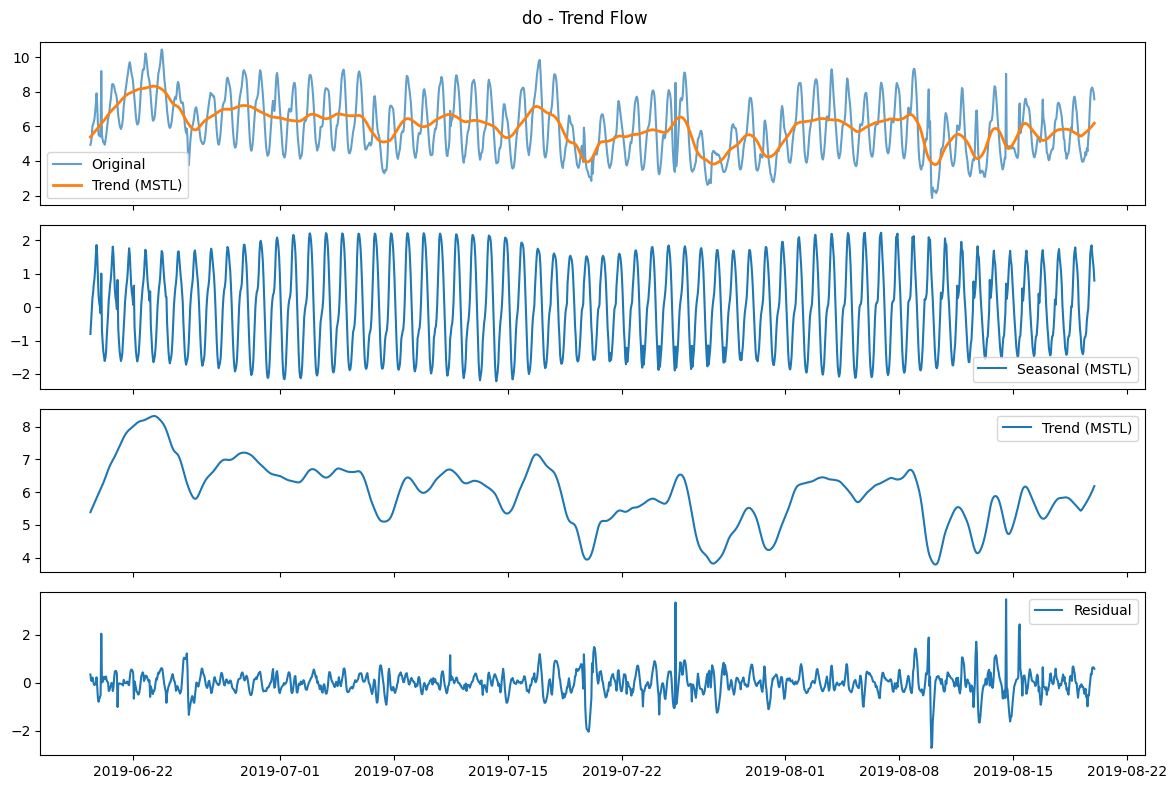

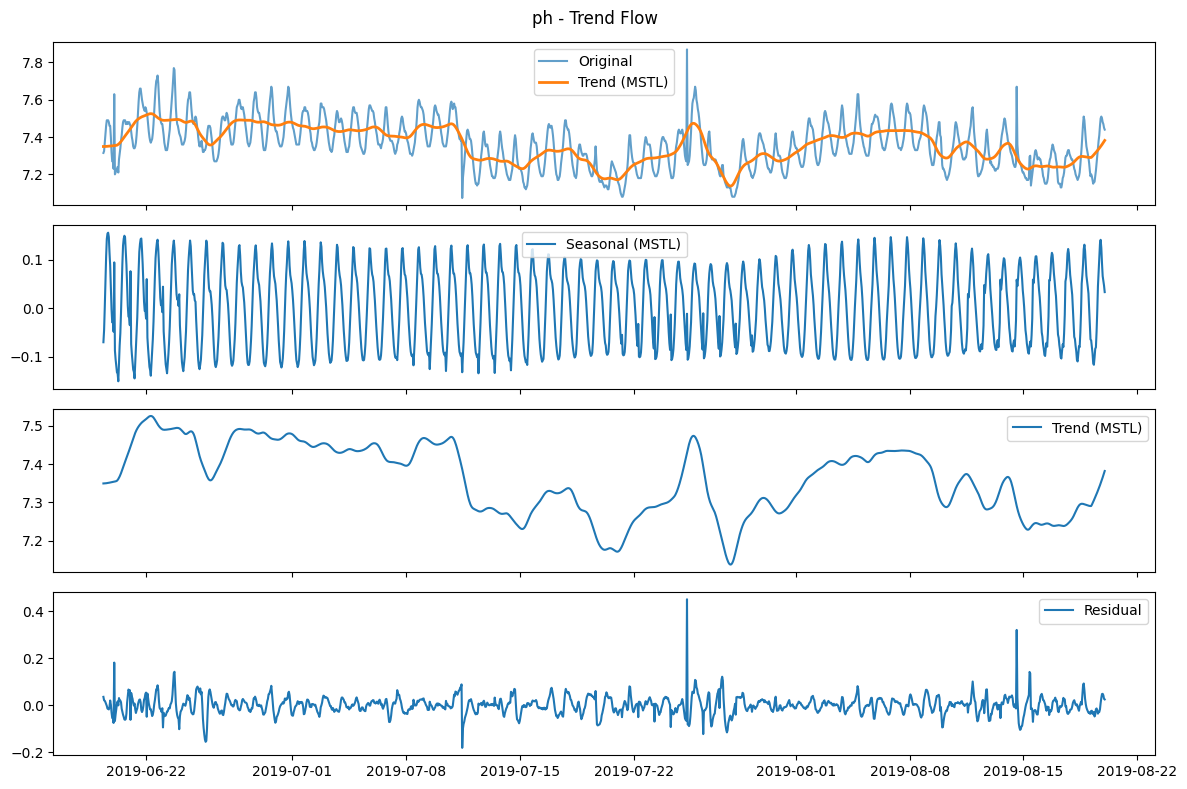

/var/tmp/ipykernel_10890/3285692810.py:38: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y = series.fillna(method='ffill').fillna(method='bfill').values


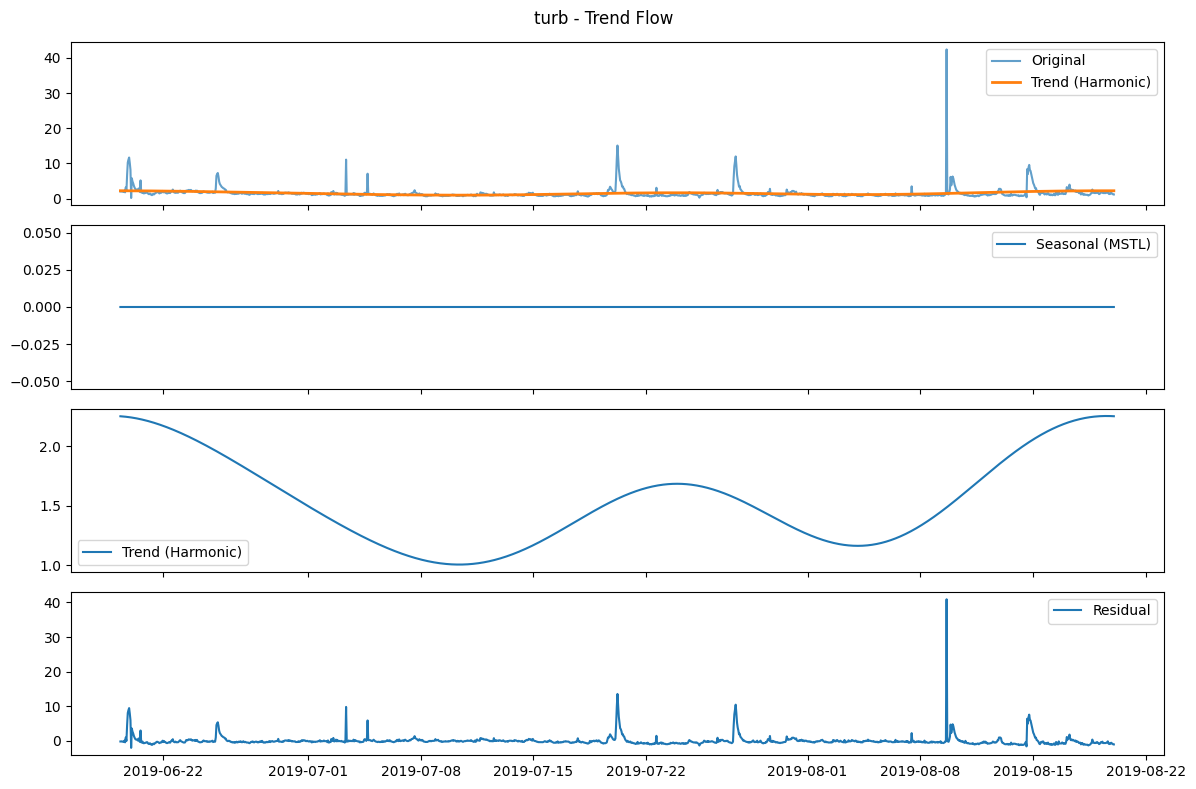

/var/tmp/ipykernel_10890/3285692810.py:38: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y = series.fillna(method='ffill').fillna(method='bfill').values


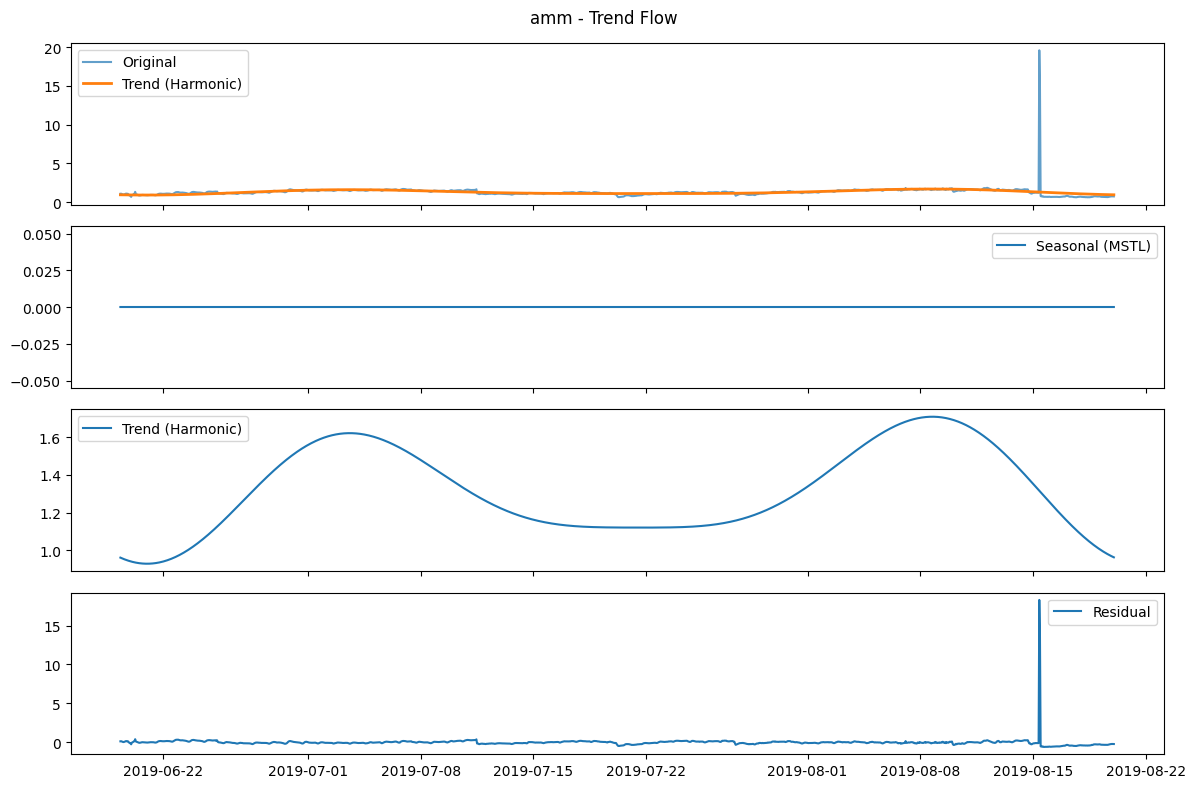

/var/tmp/ipykernel_10890/3285692810.py:38: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y = series.fillna(method='ffill').fillna(method='bfill').values


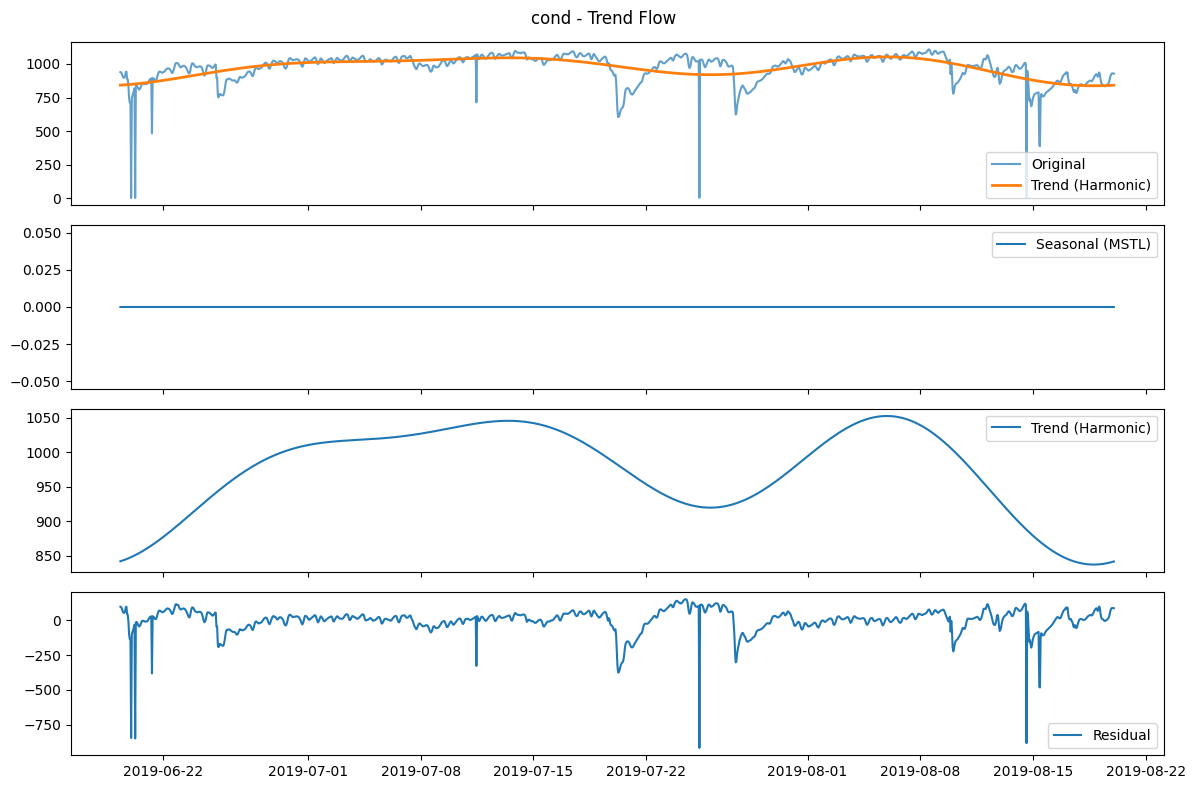

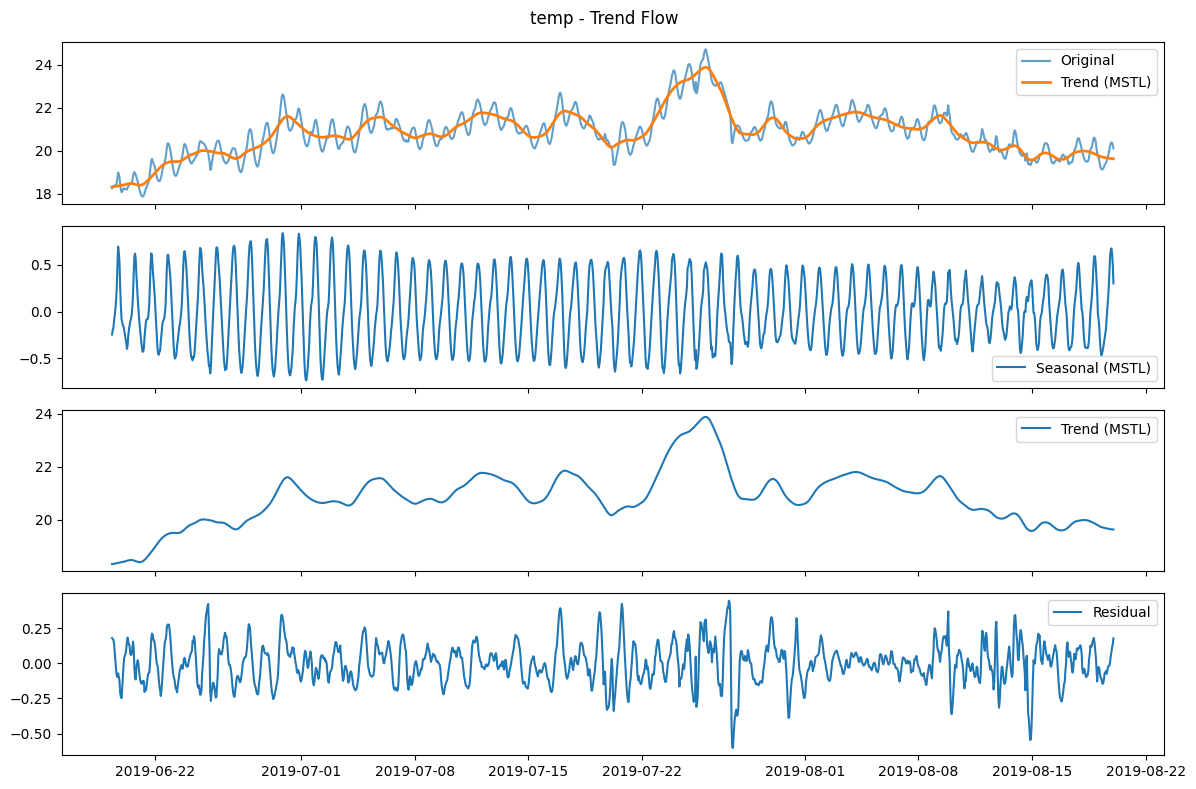

Residuals computed. Plots saved in: trend_flow_plots_2025-12-21_18-07-43


KeyError: 'poly_deg'

In [10]:
import os, shutil
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy.signal import butter, filtfilt
from statsmodels.tsa.seasonal import MSTL


stl_kwargs = { "seasonal":0}





# ----------------------------
# Helper functions
# ----------------------------

def butterworth_trend(series, cutoff_fraction=0.05, order=3):
    """Apply Butterworth low-pass filter to extract trend."""
    series_clean = series.fillna(method='ffill').fillna(method='bfill').values
    if len(series_clean) < 3:
        return pd.Series(np.zeros_like(series), index=series.index)
    b, a = butter(N=order, Wn=cutoff_fraction, btype='low', analog=False)
    trend = filtfilt(b, a, series_clean)
    return pd.Series(trend, index=series.index)

def harmonic_regression(series, max_harmonics=3):
    """Fit harmonic regression (sin/cos) to series and return trend + R2."""
    x = np.arange(len(series))
    X = np.ones((len(series), 1))  # intercept
    for k in range(1, max_harmonics + 1):
        X = np.column_stack([X, np.sin(2 * np.pi * k * x / len(series)), np.cos(2 * np.pi * k * x / len(series))])
    model = LinearRegression()
    y = series.fillna(method='ffill').fillna(method='bfill').values
    model.fit(X, y)
    trend = model.predict(X)
    score = r2_score(y, trend)
    return pd.Series(trend, index=series.index), score

def mstl_multi_period(series, periods, stl_kwargs=None):
    """Perform MSTL multi-period decomposition."""
    series_nonan = series.dropna()
    candidate_info = []
    if len(series_nonan) < 5 or not periods:
        return pd.Series(0.0, index=series.index), candidate_info, pd.Series(0.0, index=series.index)
    valid_periods = [p for p in periods if 1 < p <= len(series_nonan) // 2]
    if not valid_periods:
        return pd.Series(0.0, index=series.index), candidate_info, pd.Series(0.0, index=series.index)
    
    windows = []
    for p in valid_periods:
        w = int(round(p / 2))
        if w % 2 == 0: w += 1
        w = max(7, min(w, len(series_nonan)-1))
        if w % 2 == 0: w -= 1
        windows.append(w)
    
    try:
        mstl = MSTL(series_nonan, periods=valid_periods, windows=windows, stl_kwargs=stl_kwargs).fit()
        seasonal_arr = np.asarray(mstl.seasonal)
        seasonal_sum = seasonal_arr.sum(axis=1) if seasonal_arr.ndim > 1 else seasonal_arr
        seasonal_full = pd.Series(seasonal_sum, index=series_nonan.index).reindex(series.index).fillna(0.0)
        for i, p in enumerate(valid_periods):
            seasonal_component = seasonal_arr[:, i] if seasonal_arr.ndim > 1 else seasonal_arr
            resid_component = series_nonan.values - np.asarray(mstl.trend) - seasonal_component
            strength = 1 - (np.var(resid_component) / (np.var(resid_component + seasonal_component) + 1e-12))
            candidate_info.append({
                "period": p,
                "strength": float(strength),
                "trend": pd.Series(mstl.trend, index=series_nonan.index),
                "seasonal_component": pd.Series(seasonal_component, index=series_nonan.index)
            })
        return seasonal_full, candidate_info, pd.Series(mstl.trend, index=series.index).interpolate().ffill().bfill()
    except Exception as e:
        print(f"MSTL failed for periods {valid_periods}: {e}")
        return pd.Series(0.0, index=series.index), candidate_info, pd.Series(0.0, index=series.index)

# ----------------------------
# Main function
# ----------------------------

def compute_trend_flow(
    df,
    df_hourly=None,
    infer_periods_kwargs=None,
    stl_kwargs=None,
    out_dir_prefix="trend_flow_plots",
    plot="both"
):
    """Compute MSTL/harmonic/Butterworth trend and residuals per column."""
    
    # --- Prepare output directory ---
    if plot in ("save", "both"):
        for item in os.listdir():
            if os.path.isdir(item) and item.startswith(out_dir_prefix + "_"):
                try: shutil.rmtree(item)
                except Exception: pass
        timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
        out_dir = f"{out_dir_prefix}_{timestamp}"
        os.makedirs(out_dir, exist_ok=True)
    else:
        out_dir = None
    
    residuals = pd.DataFrame(index=df.index)
    trend_info = {}
    candidate_periods = {}
    
    # --- Candidate periods ---
    if df_hourly is not None and infer_periods_kwargs is not None:
        periods_by_param = extractPeriods(df_hourly, **infer_periods_kwargs)
    else:
        periods_by_param = {c: [] for c in df.columns}
    
    # ===============================
    #       MAIN LOOP PER COLUMN
    # ===============================
    for col in df.columns:
        if not np.issubdtype(df[col].dtype, np.number):
            residuals[col] = df[col]
            trend_info[col] = {"method": "non-numeric"}
            candidate_periods[col] = []
            continue
        
        series = df[col]
        periods = periods_by_param.get(col, [])
        
        # --- Check periodicity ---
        if periods:
            # MSTL for periodic series
            seasonal_mstl, candidate_info, trend_series = mstl_multi_period(series, periods, stl_kwargs)
            deseasoned_series = series - seasonal_mstl
            trend_method = "MSTL"
        else:
            seasonal_mstl = pd.Series(0.0, index=series.index)
            deseasoned_series = series
            # Harmonic regression for non-periodic series
            trend_series, r2 = harmonic_regression(series)
            trend_method = "Harmonic"
            if r2 >= 0.374:
                trend_series = butterworth_trend(trend_series, cutoff_fraction=0.05, order=3)
                trend_method += " + Butterworth"
        
        # --- Store info ---
        trend_info[col] = {
            "method": trend_method
        }
        candidate_periods[col] = candidate_info
        
        # --- Residual ---
        residuals[col] = series - seasonal_mstl - trend_series
        
        # --- Plot ---
        if plot is not None:
            fig, axs = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
            axs[0].plot(series.index, series, label="Original", alpha=0.7)
            axs[0].plot(series.index, trend_series, label=f"Trend ({trend_method})", linewidth=2)
            axs[0].legend()
            axs[1].plot(series.index, seasonal_mstl, label="Seasonal (MSTL)")
            axs[1].legend()
            axs[2].plot(series.index, trend_series, label=f"Trend ({trend_method})")
            axs[2].legend()
            axs[3].plot(series.index, residuals[col], label="Residual")
            axs[3].legend()
            plt.suptitle(f"{col} - Trend Flow")
            plt.tight_layout()
            if plot in ("save", "both") and out_dir is not None:
                plt.savefig(os.path.join(out_dir, f"{col}_trend_flow.png"), dpi=600)
            if plot in ("show", "both"):
                plt.show()
            plt.close(fig)
    
    residuals = residuals.dropna(how="all")
    return residuals, candidate_periods, trend_info, out_dir



# --- Example usage ---
infer_kwargs = dict(
    snr_threshold=500,
    min_period_rows=4,
    max_period_rows=int(1.2 * 24 * 365),
    nperseg_opt="full",
    nfft_mult=8.0,
    peak_prominence=0.0,
    rel_merge_tol=0.03,
    max_periods=5,
    refine=True,
    refine_span=0.10,
    refine_grid=101
)

residuals, best_periods, poly_info, mstl_dir = compute_trend_flow(
    Tidied_DF,
    df_hourly=df_hourly,
    infer_periods_kwargs=infer_kwargs,
    stl_kwargs=stl_kwargs,
    plot="both"
)

print("Residuals computed. Plots saved in:", mstl_dir)

for var in Tidied_DF.columns:
    info = poly_info[var]
    print(f"\n{var} → method={info['method']}, poly_deg={info['poly_deg']}")

    periods = best_periods[var]
    if periods:
        for c in periods:
            print(f"  MSTL candidate → period: {c['period']}, strength: {c['strength']:.3f}")
    else:
        print("  MSTL candidate → none")

df.to_csv('output.csv', index=False)




In [ ]:
residuls_save = residuals
residuls_save

# Joint Isolation Forest Anomaly Detection

- **Step 1:** Fit an `IsolationForest` on all residual columns **jointly** to detect anomalies automatically (`contamination='auto'`).  
- **Step 2:** Flag anomalies as `1` (anomaly) and `0` (normal).  
- **Step 3:** Plot residuals for each variable with **joint anomalies highlighted in red**.  
- Provides a visual overview of unusual deviations across multiple variables simultaneously.


In [ ]:
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import pandas as pd

# ----- Step 1: Compute Isolation Forest anomalies jointly -----
clf = IsolationForest(contamination='auto', random_state=42)
preds = clf.fit_predict(residuals)

# Flag anomalies: 1 = anomaly, 0 = normal
residuals_anom = pd.Series((preds == -1).astype(int), index=residuals.index, name="joint_anomaly")

# ----- Step 2: Plot residuals with anomalies -----
variables = residuals.columns
n_vars = len(variables)

# Always create a new figure to avoid overlap
fig, axs = plt.subplots(n_vars, 1, figsize=(15, 3*n_vars), sharex=True)

# Ensure axs is iterable even for n_vars = 1
if n_vars == 1:
    axs = [axs]

for i, col in enumerate(variables):
    axs[i].plot(residuals.index, residuals[col], label=f'{col} Residual', color='blue')
    
    # Highlight anomalies in red (joint anomalies)
    anom_idx = residuals.index[residuals_anom == 1]  # safer alignment
    axs[i].scatter(anom_idx, residuals.loc[anom_idx, col], color='red', label='Joint Anomaly', s=10)
    
    axs[i].set_ylabel(col)
    axs[i].legend(loc='upper right')

plt.xlabel("Time")
plt.suptitle("Residuals with Joint Isolation Forest Anomalies")
plt.tight_layout()
plt.show()





In [ ]:
# Combine residuals and anomalies into one DataFrame
residuals_combined = residuals.copy()  # start with residuals
residuals_combined['joint_anomaly'] = residuals_anom  # add anomaly column

# Optional: check the first few rows
print(residuals_combined.head())


# (Validation Section) Data Ingestion from expert labelling

- **Step 1:** This section ingest and preprocess the validation data.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ======================================
# 1. Load file
# ======================================
path = "loc_LLS_SCREEN2(loc_LLS).csv"
df = pd.read_csv(path, low_memory=False)

# Strip whitespace from column names
df.columns = df.columns.str.strip()

# ======================================
# 2. Parse datetime
# ======================================
df["dateTime"] = pd.to_datetime(
    df["dateTime"],
    errors="coerce"
)

df = df.dropna(subset=["dateTime"])
df = df.sort_values("dateTime").set_index("dateTime")

# ======================================
# 3. APPLY DATE RANGE FILTER  ✅ NEW
# ======================================
start_date = pd.to_datetime("2019-06-19")
end_date   = pd.to_datetime("2019-08-17") + pd.Timedelta(days=1)  # inclusive

df = df.loc[start_date:end_date]

print(f"Filtered data from {df.index.min()} to {df.index.max()}")

# ======================================
# 4. Define variable ↔ anomaly pairs
# ======================================
pairs = [
    ("do",   "Anomaly 1"),
    ("ph",   "Anomaly 1.1"),
    ("turb", "Anomaly 1.2"),
    ("amm",  "Anomaly 1.3"),
]

value_cols   = [v for v, _ in pairs if v in df.columns]
anomaly_cols = [a for _, a in pairs if a in df.columns]

print("Using value columns:", value_cols)
print("Using anomaly columns:", anomaly_cols)

# ======================================
# 5. Force numeric (only existing cols)
# ======================================
for col in value_cols + anomaly_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# ======================================
# 6. Hourly mean (numeric only)
# ======================================
df_hourly = df[value_cols].resample("1H").mean()

# ======================================
# 7. Build SPREAD anomaly timestamps
# ======================================
if anomaly_cols:
    combined_anomaly_times = df.index[df[anomaly_cols].any(axis=1)]
    combined_anomaly_hour_bins = combined_anomaly_times.round("1H")
else:
    combined_anomaly_hour_bins = pd.DatetimeIndex([])

combined_anomaly_hour_bins.to_series().to_csv("anomaly_timestamps.csv")

# ======================================
# 8. Save cleaned data
# ======================================
df.to_csv("cleaned_full_resolution.csv")
df_hourly.to_csv("hourly_mean.csv")

print("Saved: cleaned_full_resolution.csv, hourly_mean.csv, anomaly_timestamps.csv")

# ======================================
# 9. Plot each variable + SPREAD anomalies
# ======================================
for var in value_cols:
    plt.figure(figsize=(14, 6))

    plt.plot(
        df_hourly.index,
        df_hourly[var],
        label=f"{var} (hourly mean)",
        linewidth=2
    )

    if len(combined_anomaly_hour_bins) > 0:
        values = df_hourly[var].reindex(combined_anomaly_hour_bins)

        plt.scatter(
            values.index,
            values.values,
            marker="x",
            s=60,
            color="red",
            label="Spread anomalies"
        )

    plt.title(f"{var} with SPREAD anomalies\n({start_date.date()} → {end_date.date()})")
    plt.xlabel("Time")
    plt.ylabel(var)
    plt.legend()
    plt.grid(True)

    plt.savefig(f"{var}_spread_anomalies.png", dpi=200, bbox_inches="tight")

plt.show()

print("Saved plots: *_spread_anomalies.png")

# ======================================
# 10. Joint anomaly flag (full resolution)
# ======================================
if anomaly_cols:
    df["joint_anomaly"] = df[anomaly_cols].any(axis=1).astype(int)
else:
    df["joint_anomaly"] = 0

print(df.head())


In [ ]:
# ------------------------------
# 1. Data
# ------------------------------
data_vars = residuals_combined  # your computed residuals

# Ensure datetime index
if not pd.api.types.is_datetime64_any_dtype(data_vars.index):
    data_vars.index = pd.to_datetime(data_vars.index)

# Use your cleaned df as ground truth
ground_df = df.copy()
if 'joint_anomaly' in ground_df.columns:
    ground_df = ground_df.rename(columns={'joint_anomaly': 'joint_anomaly_gd'})

# ------------------------------
# 2. Align ground truth anomalies to nearest data_vars timestamp
# ------------------------------
gt_anoms = ground_df.index[ground_df['joint_anomaly_gd'] == 1]

# Map to nearest data_vars index
gt_idx_positions = data_vars.index.get_indexer(gt_anoms, method='nearest')
gt_anom_idx = data_vars.index[gt_idx_positions[gt_idx_positions != -1]]

# Data_vars anomalies (if column exists)
dv_anom_idx = data_vars.index[data_vars.get('joint_anomaly', 0) == 1]

print(f"Aligned ground truth anomalies: {len(gt_anom_idx)}")
print(f"Data vars anomalies: {len(dv_anom_idx)}")

# ------------------------------
# 3. Common variables
# ------------------------------
common_vars = list(set(data_vars.columns).intersection(ground_df.columns))
print(f"Common variables: {common_vars}")

# ------------------------------
# 4. Create output folder for plots
# ------------------------------
out_dir = "validation_plots"
os.makedirs(out_dir, exist_ok=True)

# ------------------------------
# 5. Plot
# ------------------------------
if common_vars:
    n_vars = len(common_vars)
    fig, axs = plt.subplots(n_vars, 1, figsize=(20, 4*n_vars), sharex=True)
    if n_vars == 1:
        axs = [axs]

    for i, col in enumerate(common_vars):
        vals = data_vars[col]

        # Plot variable lines
        axs[i].plot(data_vars.index, vals, label='data_vars', color='blue', alpha=0.7)
        gt_aligned = ground_df[col].reindex(data_vars.index, method='nearest')
        axs[i].plot(data_vars.index, gt_aligned, 
                    label='ground truth', color='orange', alpha=0.7)

        # Vertical offsets for anomalies
        y_range = vals.max() - vals.min()
        offset_dv = 0.02 * y_range
        offset_gt = 0.08 * y_range

        # Overlay anomalies
        if len(dv_anom_idx) > 0:
            axs[i].scatter(dv_anom_idx, vals.loc[dv_anom_idx] + offset_dv,
                           color='red', s=100, marker='x', label='Data Vars Joint Anomaly')
        if len(gt_anom_idx) > 0:
            axs[i].scatter(gt_anom_idx, vals.loc[gt_anom_idx] + offset_gt,
                           color='green', s=100, marker='o', label='Ground Truth Joint Anomaly')

        axs[i].set_title(col)
        axs[i].set_ylabel(col)
        axs[i].legend(loc='upper right')

    plt.xlabel("Time")
    plt.suptitle("Common Variables with Joint Anomalies Overlayed")
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    # Save figure
    plot_path = os.path.join(out_dir, "joint_anomalies_validation.png")
    plt.savefig(plot_path, dpi=600)
    plt.close(fig)

    print(f"Validation plot saved to: {plot_path}")

else:
    print("No common variables to plot.")


In [ ]:
gt_anom_idx

In [ ]:
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

# ------------------------------
# 1. Align indices
# ------------------------------
data_index = data_vars.index
ground_anom_aligned = ground_df['joint_anomaly_gd'].reindex(data_index, method='nearest', fill_value=0)

# True labels (ground truth)
y_true = ground_anom_aligned.astype(int)

# Predicted labels (data_vars anomalies)
y_pred = data_vars['joint_anomaly'].reindex(data_index, fill_value=0).astype(int)

# ------------------------------
# 2. Compute confusion matrix
# ------------------------------
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix: Data Vars vs Ground Truth")
plt.show()

# Extract TP, TN, FP, FN
TN, FP, FN, TP = cm.ravel()

# ------------------------------
# 3. Compute metrics
# ------------------------------
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

# ------------------------------
# 4. Print results
# ------------------------------
print("===== Confusion Matrix Counts =====")
print(f"True Positives (TP):  {TP}")
print(f"True Negatives (TN):  {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}\n")

print("===== Evaluation Metrics =====")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")



# Combine Residuals with Anomaly Flags

- Create a **Series `residuals_anom`** from the joint Isolation Forest model (`1 = anomaly, 0 = normal`).   
- Resulting DataFrame contains both **residual values** and a **unified anomaly indicator** for easy analysis.


In [ ]:
# residuals_anom is a Series from joint model
residuals_anom = pd.Series(
    (preds == -1).astype(int),
    index=residuals.index,
    name="any_anomaly"
)

# Merge residuals and anomaly flag into one DataFrame
residuals_with_flags = residuals.copy()
residuals_with_flags["any_anomaly"] = residuals_anom


In [ ]:
# Make a copy to avoid modifying the original
Tidied_DF = Tidied_DF.copy()

# Add default anomaly columns
Tidied_DF['Anomalous'] = 0
for col in residuals.columns:
    Tidied_DF[f"{col}_anomaly"] = 0

# Fill in anomalies from joint residuals_anom
anomaly_idx = residuals_anom.index[residuals_anom == 1]
Tidied_DF.loc[anomaly_idx, 'Anomalous'] = 1
for col in residuals.columns:
    Tidied_DF.loc[anomaly_idx, f"{col}_anomaly"] = 1  # mark all as 1 if joint anomaly


# Rename 'any_anomaly' column to 'Anomalous'
Tidied_DF.rename(columns={'any_anomaly': 'Anomalous'}, inplace=True)    
    
# Check first 10 rows
print(Tidied_DF.head(10))


In [ ]:
# Keep only rows where any one variable is anomalous. Note that we filter all the variable even if one value is anomalous
Anomalous_DF = residuals_with_flags[Tidied_DF['Anomalous'] == 1]

# Clustering
The goal is to analyze multivariate residuals from sensor or time series data to detect unusual patterns and deviations. By scaling the data, performing clustering, and visualisation, we can identify relationships between variables, highlight periods of abnormal behavior, and summarize complex high-dimensional information in a comprehensible 2D biplot. This approach aids in monitoring, anomaly detection, and decision-making for environmental, industrial, or scientific datasets.

# PCA Biplot

A **PCA biplot** is a visualization tool that combines **principal component analysis (PCA)** results with information about the original variables:

- **Principal Components (PCs):** The points in the biplot represent the observations (rows of your data) projected onto the first two principal components (PC1 and PC2), which capture the largest variance in the dataset.
- **Variable Vectors:** Arrows indicate the contribution (loadings) of each original variable to the PCs. The direction and length show how strongly each variable influences the components.
- **Interpretation:**
  - Points close together have similar patterns across variables.
  - Arrows pointing in the same direction indicate correlated variables.
  - Arrows perpendicular to each other indicate variables that are uncorrelated.
- **Use in Residual Clustering:** In your workflow, the PCA biplot helps to visualize **how residuals (or deviations) cluster together** and how each variable contributes to cluster separation.

✅ **Benefit:** It reduces high-dimensional data to two dimensions while preserving as much variance as possible, making patterns easier to interpret visually.



In [ ]:

# ================== Step 0: Prepare filtered residuals ==================
filtered_residuals = Anomalous_DF.copy()
feature_names = filtered_residuals.columns.tolist()

# ================== Step 1: Scaling ==================
scaler_resid = StandardScaler()
X_resid = scaler_resid.fit_transform(filtered_residuals)

# ================== Step 2: Determine optimal k using Silhouette ==================
def optimal_k(X, max_k=25):
    sil_scores = []

    for k in range(2, max_k + 1):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)
        sil_scores.append(silhouette_score(X, labels))

    # Plot Silhouette
    plt.figure(figsize=(6,4))
    plt.plot(range(2, max_k+1), sil_scores, marker='o', color='orange')
    plt.xlabel('Number of clusters')
    plt.ylabel('Silhouette Score')
    plt.title('Silhouette Scores')
    plt.grid(True)
    plt.show()

    # Best k from silhouette
    k_opt = np.argmax(sil_scores) + 2  # +2 because range starts at 2
    print(f"Silhouette suggests k={k_opt}")
    return k_opt

k_resid = optimal_k(X_resid)

# ================== Step 3: KMeans on residuals ==================
kmeans_resid = KMeans(n_clusters=k_resid, random_state=42, n_init=50)
filtered_residuals['ClusterID'] = kmeans_resid.fit_predict(X_resid)
labels_resid = filtered_residuals['ClusterID'].values

# ================== Step 4: Time Series Plots ==================
fig, axs = plt.subplots(len(feature_names), 1, figsize=(16, 2.5 * len(feature_names)), sharex=True)
if len(feature_names) == 1: axs = [axs]
colors = plt.get_cmap('tab10', k_resid)

for i, col in enumerate(feature_names):
    axs[i].scatter(filtered_residuals.index, filtered_residuals[col],
                   c=[colors(l) for l in labels_resid], s=10)
    axs[i].set_ylabel(f"{col} (Residual)")
    axs[i].grid(True)

axs[-1].set_xlabel("Time")
if pd.api.types.is_datetime64_any_dtype(filtered_residuals.index):
    axs[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ================== Step 5: Adaptive Cluster Visualization ==================
if X_resid.shape[1] >= 2:
    if X_resid.shape[1] == 2:
        # 2D scatter
        fig, ax = plt.subplots(figsize=(8,6))
        ax.scatter(X_resid[:,0], X_resid[:,1], 
                   c=[colors(l) for l in labels_resid], s=30)
        centroids = kmeans_resid.cluster_centers_
        ax.scatter(centroids[:,0], centroids[:,1], marker='X', c='black', s=100, label='Centroids')
        ax.set_xlabel(feature_names[0])
        ax.set_ylabel(feature_names[1])
        ax.set_title('2D KMeans Clusters (Residuals)')
        ax.legend()
        plt.grid(True)
        plt.show()

    else:
        # 3D scatter
        fig_cluster = plt.figure(figsize=(12,6))
        ax = fig_cluster.add_subplot(111, projection='3d')
        X_plot = X_resid[:, :3]

        ax.scatter(X_plot[:,0], X_plot[:,1], X_plot[:,2],
                   c=[colors(l) for l in labels_resid], s=15)

        centroids = kmeans_resid.cluster_centers_[:, :3]
        for i, centroid in enumerate(centroids):
            ax.text(centroid[0], centroid[1], centroid[2],
                    f'Cluster {i}', fontsize=12, fontweight='bold', color='black')

        ax.set_title('3D KMeans Clusters (Residuals)')
        ax.set_xlabel(feature_names[0])
        ax.set_ylabel(feature_names[1])
        ax.set_zlabel(feature_names[2])
        plt.tight_layout()
        plt.show()
else:
    print("Skipping cluster visualization (not enough features).")

# --- Build display names for features ---
display_names = []
for feature in feature_names:
    if feature.lower() in ["any_anomaly", "anomalous"]:
        display_names.append("Deviation")   # rename global anomaly
    elif feature.endswith("_anomaly"):
        base = feature.replace("_anomaly", "").upper()
        display_names.append(f"{base} Deviation")  # e.g. ph_anomaly → PH Deviation
    else:
        display_names.append(feature)

# --- PCA Biplot ---
if X_resid.shape[1] > 2:
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_resid)

    fig, ax = plt.subplots(figsize=(8,6))
    scatter = ax.scatter(X_pca[:,0], X_pca[:,1], c=labels_resid, cmap='tab10', s=30)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.set_title('PCA Biplot of Residuals with KMeans Clusters')

    # Add variable vectors with nicer names
    for i, label in enumerate(display_names):
        ax.arrow(0, 0,
                 pca.components_[0,i]*max(X_pca[:,0]),
                 pca.components_[1,i]*max(X_pca[:,1]),
                 color='r', alpha=0.5, head_width=0.05)
        ax.text(pca.components_[0,i]*max(X_pca[:,0])*1.1,
                pca.components_[1,i]*max(X_pca[:,1])*1.1, label, color='r')

    plt.grid(True)
    plt.show()
else:
    print("Skipping PCA biplot (not enough features).")




In [ ]:
# If dateTime is the index, reset it to make it a column
filtered_residuals = filtered_residuals.reset_index()

# Keep only the dateTime column (now a regular column) and ClusterID
filtered_residuals = filtered_residuals[['dateTime', 'ClusterID']]

In [ ]:
# Ensure dateTime is a column in both DataFrames
Tidied_DF = Tidied_DF.reset_index() if 'dateTime' not in Tidied_DF.columns else Tidied_DF
filtered_residuals = filtered_residuals.reset_index() if 'dateTime' not in filtered_residuals.columns else filtered_residuals

# Merge ClusterID
Tidied_DF = Tidied_DF.merge(
    filtered_residuals[['dateTime', 'ClusterID']],
    on='dateTime',
    how='left'   # left join keeps all rows from Tidied_DF
)

# Keep only main columns + ClusterID
columns_to_keep = ['dateTime', 'do', 'ph', 'turb', 'amm', 'cond', 'temp', 'ClusterID']
Tidied_DF = Tidied_DF[columns_to_keep]

print(Tidied_DF.head(50))

# ClusterID Over Time

This plot visualizes the evolution of cluster assignments (`ClusterID`) over time, ignoring any missing values (`NaN`). Each point represents a timestamped observation colored by its cluster. This allows us to observe temporal patterns, transitions between clusters, and periods of similar behavior in the residual data.

- **X-axis:** Date and time (`dateTime`)  
- **Y-axis:** Cluster assignment (`ClusterID`)  
- **Color:** Cluster label for easier visual distinction  
- **NaNs:** Rows with missing `ClusterID` are ignored


In [ ]:


# Ensure dateTime is datetime
Tidied_DF['dateTime'] = pd.to_datetime(Tidied_DF['dateTime'])

# Filter out rows where ClusterID is NaN
plot_df = Tidied_DF.dropna(subset=['ClusterID'])

plt.figure(figsize=(16,4))
plt.scatter(plot_df['dateTime'], plot_df['ClusterID'], c=plot_df['ClusterID'], cmap='tab10', s=15)
plt.xlabel('DateTime')
plt.ylabel('Cluster ID')
plt.title('ClusterID over Time (NaN ignored)')
plt.grid(True)

# Format x-axis nicely
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Save Clustered Residuals

After clustering, the filtered residuals with their corresponding `ClusterID` are saved for downstream analysis or reporting. The output is stored in a dedicated directory to keep results organized.

- **Output directory:** `clustered_residuals`  
- **File name:** `Tidied_DF.csv`  
- **Contents:** Filtered residuals with assigned cluster numbers (`ClusterID`)  
- **Purpose:** Preserve the clustering results for future use, visualization, or further statistical analysis  

✅ **Note:** Missing cluster assignments (`NaN`) were already excluded before saving.


In [ ]:
# ================== Save clustered residuals ==================
output_dir = "clustered_residuals"
os.makedirs(output_dir, exist_ok=True)
csv_path = os.path.join(output_dir, "Tidied_DF.csv")
plot_df.to_csv(csv_path, index=True)
print(f"✅ Processing Complete. Clustered residuals with cluster numbers saved to: {csv_path}")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Group by 'ClusterID' and calculate max, min, and mean for each numeric column
aggregated_df = Tidied_DF.groupby('ClusterID').agg(['max', 'min', 'mean'])
print("Aggregated statistics by ClusterID:")
print(aggregated_df)

# Select numeric columns
numeric_columns = Tidied_DF.select_dtypes(include='number').columns

# Set high-contrast color palette
unique_clusters = Tidied_DF['ClusterID'].nunique()
palette = sns.color_palette("Dark2", unique_clusters)

# Plot KDE distributions with fixes
for column in numeric_columns:
    plt.figure(figsize=(10, 6))
    try:
        sns.kdeplot(
            data=Tidied_DF,
            x=column,
            hue='ClusterID',
            fill=True,
            palette=palette,
            warn_singular=False  # Suppress zero variance warning
        )
        plt.title(f'Distribution of {column} by ClusterID')
        plt.xlabel(column)
        plt.ylabel('Density')
        plt.legend(title='ClusterID', loc='upper right')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Could not plot {column}: {e}")


In [ ]:
import pandas as pd

# Compute the mean of all numeric columns grouped by ClusterID
cluster_means = Tidied_DF.groupby('ClusterID').mean(numeric_only=True)

# Count non-null values for numeric columns only
numeric_cols = Tidied_DF.select_dtypes(include='number').columns
cluster_counts = Tidied_DF.groupby('ClusterID')[numeric_cols].count()

# Optionally, add a column showing the total number of numeric values averaged per cluster
cluster_means['TotalCount'] = cluster_counts.sum(axis=1)

# Display the result
print("Mean values of numeric columns grouped by ClusterID, with count of values averaged:")
print(cluster_means)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create the DataFrame
data = {
    'ClusterID': [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0],
    'do': [10.635192, 10.427364, 0.0, 10.869808, 0.068053, 6.254884, 10.231333, 8.342333, 10.587318, 11.282143, 9.458667, 0.0, 11.14343, 12.989286],
    'ph': [6.831538, 6.725182, 6.551, 6.645019, 6.667947, 6.584186, 6.505444, 6.375833, 6.600268, 6.528571, 6.790917, 6.592143, 6.693328, 7.052857],
    'turb': [43.744231, 38.449091, 1159.445333, 9.337548, 178.832632, 974.255814, 49.013333, 4.085, 9.22567, 436.342857, 52.928333, 997.167857, 9.410149, 8.392857],
    'amm': [0.45675, 0.473009, 0.786, 81.744, 1.044842, 0.250151, 0.314044, 1.673239, 43.346, 0.405357, 0.338967, 0.233875, 119.027439, 0.614214],
    'cond': [297.173077, 252.409091, 346.266667, 356.911877, 471.542105, 276.523256, 227.322222, 721.694444, 343.766284, 318.571429, 249.533333, 265.375, 365.649776, 492.214286],
    'temp': [10.692115, 10.833818, 6.0028, 9.644234, 4.945947, 10.604767, 10.964, 21.612556, 10.339272, 9.499286, 13.879167, 11.017857, 8.960854, 4.992857]
}

df = pd.DataFrame(data).set_index('ClusterID')

# Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Heatmap of Mean Values by ClusterID")
plt.tight_layout()
plt.show()

In [ ]:
# Bar plots for each feature
for column in df.columns:
    plt.figure(figsize=(10, 6))
    sns.barplot(x=df.index, y=df[column], palette="Dark2")
    plt.title(f"Mean {column} by ClusterID")
    plt.xlabel("ClusterID")
    plt.ylabel(f"Mean {column}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [ ]:
unique_clusters

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Make folder to save plots
output_folder = "cluster_boxplots"
os.makedirs(output_folder, exist_ok=True)

# Remove rows without cluster assignment
Tidied_DF = Tidied_DF.dropna(subset=['ClusterID'])

# Convert ClusterID to integer
Tidied_DF['ClusterID'] = Tidied_DF['ClusterID'].astype(int)

# Numeric columns except ClusterID
numeric_columns = [c for c in Tidied_DF.select_dtypes(include='number').columns
                   if c != 'ClusterID']

# Color palette
unique_clusters = Tidied_DF['ClusterID'].nunique()
palette = sns.color_palette("Dark2", unique_clusters)

# Generate and save plots
for column in numeric_columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(
        data=Tidied_DF,
        x='ClusterID',
        y=column,
        palette=palette
    )
    plt.title(f'Boxplot of {column} by KMeans Cluster')
    plt.tight_layout()
    
    # Save plot as PNG
    filename = os.path.join(output_folder, f'boxplot_{column}.png')
    plt.savefig(filename, dpi=300)
    plt.close()  # Close figure to free memory

print(f"All boxplots saved to folder: {output_folder}")
